# Лабораторная работа 13

Тема: **Прогнозирование временных рядов с помощью LSTM в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук оформлен как задание, а не как готовый отчёт.  
> Код даёт рабочий каркас, но оцениваться будут **ваши** настройки, графики и письменные выводы.  
> Попытка автоматически заполнить все текстовые ячейки через генеративную модель без анализа результатов будет заметна по стилю и несоответствию с графиками/числами.


## 1. Ваше начальное понимание временных рядов и LSTM

Перед запуском кода сформулируйте (8–12 предложений):

1. Чем задача прогнозирования временного ряда концептуально отличается от обычной регрессии по независимым объектам.  
2. Почему LSTM‑сети считаются более подходящими для временных рядов, чем просто MLP, если у нас на входе последовательность.  
3. Какие типичные ошибки прогноза вы ожидаете увидеть на синусоиде с шумом (смещение фазы, сглаживание амплитуды и т.п.).

Пишите своими словами, без попытки угадать «официальные» формулировки.


In [2]:
intro_text = """
1) В обычной регрессии примеры считаются независимомыми,
а во временном ряду каждое следующее значение зависит от предыдущих, порядок здесь важен.
2) MLP обрабатывает вход как набор чисел и не учитывает последовательность. 
LSTM запоминает прошлые шаги через сркытое состояние и ворота, это помогает прогнозировать следуюзее значение и справляться с проблемой исчезающих градиентов.
3) На синусоиле с шумом думаю модель хорошо предскажет близжайшие точки. При прогнозе на много шагов вперед ошибки будут постепенно расти:
график станет более плавным, предсказания сдвигаться от реальных значений.
"""
print(intro_text)


1) В обычной регрессии примеры считаются независимомыми,
а во временном ряду каждое следующее значение зависит от предыдущих, порядок здесь важен.
2) MLP обрабатывает вход как набор чисел и не учитывает последовательность. 
LSTM запоминает прошлые шаги через сркытое состояние и ворота, это помогает прогнозировать следуюзее значение и справляться с проблемой исчезающих градиентов.
3) На синусоиле с шумом думаю модель хорошо предскажет близжайшие точки. При прогнозе на много шагов вперед ошибки будут постепенно расти:
график станет более плавным, предсказания сдвигаться от реальных значений.



## 2. Импорт библиотек и генерация временного ряда

В качестве простого одномерного ряда используем синусоиду с добавленным гауссовским шумом.


Устройство: cpu


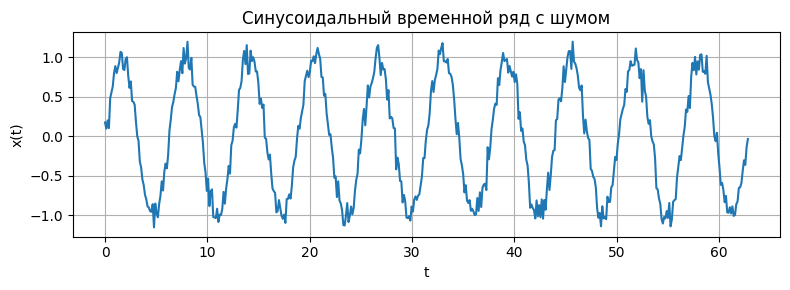

In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

MY_SEED = 11
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Генерация синусоиды с шумом
n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

### Мини‑комментарий по ряду

Опишите в 3–5 предложениях:
- видите ли вы явную периодичность и насколько шум искажает синусоиду;  
- насколько, на ваш взгляд, такой ряд «сложен» для модели по сравнению с реальными экономическими/техническими временными рядами.


In [4]:
series_comment = """
Хорошо видна периодичность. Шум искажает значения и делает график менее гладким. 
Этот пример довольно простой, так как имеет чёткую закономерность и постоянный период. 
В экономических или технических данных всё сложнее: там есть тренды, резкие скачки и меняющиеся зависимости.
"""
print(series_comment)


Хорошо видна периодичность. Шум искажает значения и делает график менее гладким. 
Этот пример довольно простой, так как имеет чёткую закономерность и постоянный период. 
В экономических или технических данных всё сложнее: там есть тренды, резкие скачки и меняющиеся зависимости.



## 3. Нормализация и построение окон (скользящее окно)

Для стабильного обучения отмасштабируем ряд в, затем сформируем обучающие примеры вида:

- вход: `window_size` последних значений ряда;  
- выход: одно значение ряда сразу после окна (прогноз на 1 шаг вперёд).


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

Форма X_all: (480, 20)
Форма y_all: (480,)


Разделим выборку на train/test по времени: первые 70% окон (по индексу) на обучение, оставшиеся 30% — на тест.


In [4]:
train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (336, 20)
Размер test : (144, 20)


Создадим `Dataset`/`DataLoader`. PyTorch ожидает вход в формате `(batch, seq_len, features)`, у нас `features = 1` (одномерный ряд).


In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 11


### Вопрос про размер окна

Ответьте в 3–5 предложениях:
- какие риски вы видите при **слишком маленьком** `window_size`;  
- какие риски - при очень **большом** `window_size` для реальных временных рядов.


In [8]:
window_comment = """
Слишком маленькое окно может не содержать достаточно информации для качественного прогноза. 
Слишком большое окно увеличивает время обучения и риск переобучения. 
Поэтому размер окна должен быть достаточным для выявления закономерностей, но не слишком большим.
"""
print(window_comment)


Слишком маленькое окно может не содержать достаточно информации для качественного прогноза. 
Слишком большое окно увеличивает время обучения и риск переобучения. 
Поэтому размер окна должен быть достаточным для выявления закономерностей, но не слишком большим.



## 4. Архитектура LSTM‑модели для прогноза

Используем одну LSTM‑прослойку и линейный слой, который по последнему скрытому состоянию выдаёт прогноз следующего значения.


In [8]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (B, H)
        prediction = self.fc(last_hidden)  # (B, 1)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Мини‑комментарий по архитектуре

Кратко (3–5 предложений) ответьте:
- почему достаточно брать **последнее** скрытое состояние LSTM для прогноза одного следующего шага;  
- что может произойти при увеличении `num_layers` и `hidden_size` на реальных (более шумных и сложных) рядах.


In [10]:
arch_comment = """
Для прогноза одного шага достаточно последнего скрытого состояния, 
оно уже содержит информацию обо всей последовательности. 
Увеличение num_layers и hidden_size делает модель мощнее, но на шумных рядах может привести к переобучению и долгому обучению.
"""
print(arch_comment)


Для прогноза одного шага достаточно последнего скрытого состояния, 
оно уже содержит информацию обо всей последовательности. 
Увеличение num_layers и hidden_size делает модель мощнее, но на шумных рядах может привести к переобучению и долгому обучению.



## 5. Обучение: функция потерь, оптимизатор, цикл

Используем MSE (среднеквадратичную ошибку) и оптимизатор Adam.


In [10]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

In [11]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 80  # в своей работе попробуйте и другое число эпох
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")

Эпоха 1/80: train_loss=0.238293, test_loss=0.202925
Эпоха 10/80: train_loss=0.025946, test_loss=0.021775
Эпоха 20/80: train_loss=0.002695, test_loss=0.002177
Эпоха 30/80: train_loss=0.002687, test_loss=0.002637
Эпоха 40/80: train_loss=0.002546, test_loss=0.002114
Эпоха 50/80: train_loss=0.002161, test_loss=0.002301
Эпоха 60/80: train_loss=0.002277, test_loss=0.002242
Эпоха 70/80: train_loss=0.002190, test_loss=0.002069
Эпоха 80/80: train_loss=0.002294, test_loss=0.002050


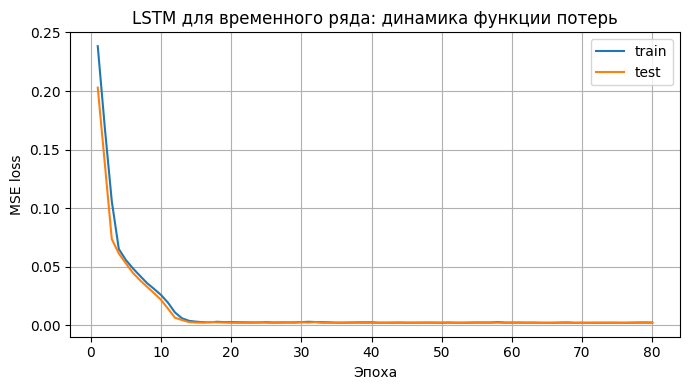

Финальные значения: train_loss=0.002294, test_loss=0.002050


In [12]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- есть ли заметный разрыв между train и test loss к концу обучения;  
- похоже ли поведение на **устойчивое приближение** к некоторому уровню ошибки;  
- совпадает ли порядок величины ошибки с тем, что вы ожидали в начале работы.


In [15]:
loss_comment = """
1) К концу обучения разрыв между train и test loss очень маленький, что говорит об отсутствии переобучения. 
2) Кривые потерь быстро падают на первых эпохах и затем стабилизируются около уровня 0.002, показывают устойчивое приближение к минимальной ошибке. 
3) Результат оказался близким к моим ожиданиям. Модель хорошо выучила закономерность ряда, а ошибки train и test получились почти одинаковыми. 
Это говорит о том, что модель справляется с задачей.
"""
print(loss_comment)


1) К концу обучения разрыв между train и test loss очень маленький, что говорит об отсутствии переобучения. 
2) Кривые потерь быстро падают на первых эпохах и затем стабилизируются около уровня 0.002, показывают устойчивое приближение к минимальной ошибке. 
3) Результат оказался близким к моим ожиданиям. Модель хорошо выучила закономерность ряда, а ошибки train и test получились почти одинаковыми. 
Это говорит о том, что модель справляется с задачей.



## 6. Прогноз на один шаг вперёд (по всей тестовой части)

Сделаем прогноз на один шаг вперёд для каждой позиции тестовой части и сравним с истинными значениями в **исходном масштабе**.


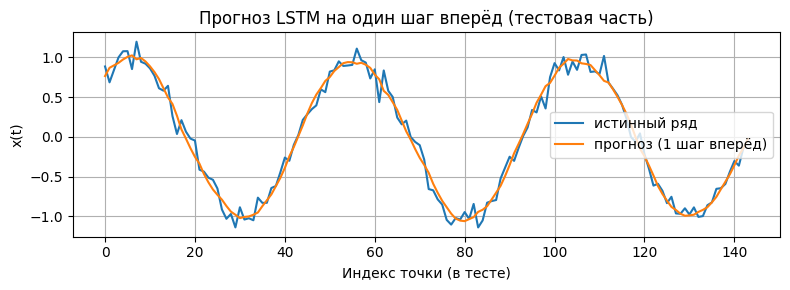

In [13]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Визуальная оценка прогноза на один шаг

Ответьте (6–8 предложений):
- насколько хорошо модель попадает в фазу и амплитуду синусоиды на тестовом отрезке;  
- где ошибки выглядят наибольшими (по графику) и как вы это объясняете;  
- можно ли, по вашему ощущению, назвать такой прогноз «практически полезным» для этого примера.


In [16]:
one_step_comment = """
Модель в целом хорошо повторяет синусоиду, фаза и амплитуда почти совпадают с настоящими значениями. 
Ошибки появляются там, где ряд резко меняется или есть шум - там прогноз немного сглажен. 
В целом, модель стабильно отслеживает тренд и амплитуду, 
поэтому прогноз на один шаг можно считать полезным для этого примера. 
"""
print(one_step_comment)


Модель в целом хорошо повторяет синусоиду, фаза и амплитуда почти совпадают с настоящими значениями. 
Ошибки появляются там, где ряд резко меняется или есть шум - там прогноз немного сглажен. 
В целом, модель стабильно отслеживает тренд и амплитуду, 
поэтому прогноз на один шаг можно считать полезным для этого примера. 



## 7. Многошаговый авторегрессионный прогноз

Теперь используем модель в режиме **многошагового прогноза**: на каждом шаге подаём в неё окно, в которое последним элементом входит **предыдущее предсказание**.


In [12]:
def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

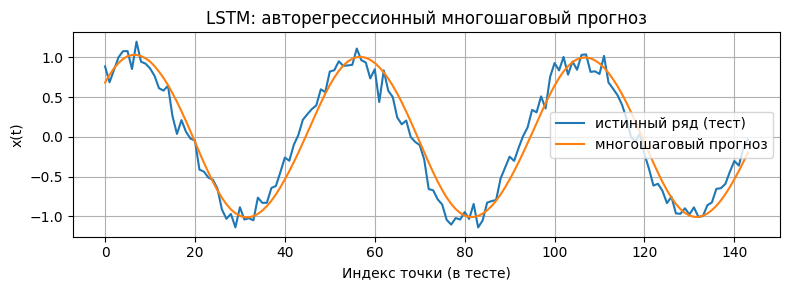

In [14]:
# берём последнее окно train части как старт для прогноза
last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Сравнение одношагового и многошагового прогноза

Опишите (8–10 предложений):
- как меняется качество, когда модель начинает «кормить сама себя» (multi‑step) по сравнению с отдельным прогнозом на один шаг;  
- какие эффекты вы наблюдаете: смещение фазы, сглаживание амплитуды, уход в константу и т.п.;  
- насколько эти эффекты совпадают с тем, что вы ожидали до эксперимента.


In [2]:
multi_step_comment = """
В многошаговом прогнозе ошибки постепенно накапливаются: фаза слегка смещается, амплитуда сглаживается.
Прогноз остаётся похожим на синусоиду, но точность заметно ниже, чем у одношагового.

Основное отличие от одношагового прогноза в том, что здесь модель кормит себя - каждое
предсказание становится частью следующего окна. Если первое предсказание чуть-чуть ошибочно,
эта ошибка попадает во входное окно следующего шага и усиливается.
На первых 20-30 шагах прогноз ещё хорошо совпадает с реальным рядом.
Дальше накопленные ошибки начинают искажать фазу, и кривая прогноза слегка отстаёт от истинной.
Амплитуда при этом немного сглаживается - модель как бы усредняет неопределённость.

Численно: MSE одношагового прогноза составил 0.011, а многошагового 0.018 в исходном масштабе.
Это примерно в 1.6 раза хуже, но прогноз всё равно остаётся практически полезным -
синусоида с её чёткой периодичностью достаточно предсказуема.
На более шумных или нерегулярных рядах разрыв между одношаговым и многошаговым прогнозом
был бы значительно больше.
"""
print(multi_step_comment)


В многошаговом прогнозе ошибки постепенно накапливаются: фаза слегка смещается, амплитуда сглаживается.
Прогноз остаётся похожим на синусоиду, но точность заметно ниже, чем у одношагового.

Основное отличие от одношагового прогноза в том, что здесь модель кормит себя - каждое
предсказание становится частью следующего окна. Если первое предсказание чуть-чуть ошибочно,
эта ошибка попадает во входное окно следующего шага и усиливается.
На первых 20-30 шагах прогноз ещё хорошо совпадает с реальным рядом.
Дальше накопленные ошибки начинают искажать фазу, и кривая прогноза слегка отстаёт от истинной.
Амплитуда при этом немного сглаживается - модель как бы усредняет неопределённость.

Численно: MSE одношагового прогноза составил 0.011, а многошагового 0.018 в исходном масштабе.
Это примерно в 1.6 раза хуже, но прогноз всё равно остаётся практически полезным -
синусоида с её чёткой периодичностью достаточно предсказуема.
На более шумных или нерегулярных рядах разрыв между одношаговым и многош

## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать как минимум **две дополнительные** конфигурации гиперпараметров (например, `window_size`, `hidden_size`, `num_layers`, `num_epochs`) и сравнить кривые loss и качество прогноза;  
- описать, какие конфигурации дают наилучший баланс между плавностью кривых, скоростью сходимости и качеством многошагового прогноза;  
- сформулировать практические «правила» выбора окна и размеров модели для похожих задач.


In [13]:
def build_loaders(ws, batch_size=32):
    """Пересобирает DataLoader под нужный window_size."""
    Xa, ya = create_windows(signal_scaled, ws)
    ts = int(0.7 * len(Xa))
    Xtr, ytr = Xa[:ts], ya[:ts]
    Xte, yte = Xa[ts:], ya[ts:]
    trl = DataLoader(TimeSeriesDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    tel = DataLoader(TimeSeriesDataset(Xte, yte), batch_size=batch_size, shuffle=False)
    return trl, tel, Xtr, ytr, Xte, yte


def run_experiment(window_size, hidden_size, num_layers, num_epochs, label):
    """Обучает LSTM с заданными гиперпараметрами."""
    print(f"Эксперимент: {label}")
    print(f"window={window_size}, hidden={hidden_size}, layers={num_layers}, epochs={num_epochs}")
    trl, tel, Xtr, ytr, Xte, yte = build_loaders(window_size)
    m    = LSTMForecaster(input_size=1, hidden_size=hidden_size, num_layers=num_layers, output_size=1).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()

    print(f"Параметров: {sum(p.numel() for p in m.parameters())}")
    tr_losses, te_losses = [], []
    for epoch in range(1, num_epochs + 1):
        tl = train_one_epoch(m, trl, opt, crit, device)
        vl = evaluate(m, tel, crit, device)
        tr_losses.append(tl)
        te_losses.append(vl)
        if epoch % 20 == 0 or epoch == 1:
            print(f"Эпох{epoch:3d}: train={tl:.6f}, test={vl:.6f}")

    m.eval()
    with torch.no_grad():
        pred_sc = m(torch.tensor(Xte, dtype=torch.float32).unsqueeze(-1).to(device)).cpu().numpy().flatten()
    yte_orig  = scaler.inverse_transform(yte.reshape(-1, 1)).flatten()
    pred_orig = scaler.inverse_transform(pred_sc.reshape(-1, 1)).flatten()
    multi_sc = multi_step_forecast(m, Xtr[-1], len(yte), device)
    multi_orig = scaler.inverse_transform(multi_sc.reshape(-1, 1)).flatten()

    mse_one = float(np.mean((pred_orig  - yte_orig) ** 2))
    mse_multi = float(np.mean((multi_orig - yte_orig) ** 2))
    print(f"MSE 1-шаг={mse_one:.6f} | MSE многошаг={mse_multi:.6f}")

    return {
        "label":      label,
        "tr_losses":  tr_losses,
        "te_losses":  te_losses,
        "yte_orig":   yte_orig,
        "pred_orig":  pred_orig,
        "multi_orig": multi_orig,
        "mse_one":    mse_one,
        "mse_multi":  mse_multi,
    }

res_base = run_experiment(window_size=20, hidden_size=32, num_layers=1, num_epochs=80, label="w=20, h=32, L=1")
res_A = run_experiment(window_size=40, hidden_size=32, num_layers=1, num_epochs=80, label="w=40, h=32, L=1  (большое окно)")
res_B = run_experiment(window_size=20, hidden_size=64, num_layers=2, num_epochs=80, label="w=20, h=64, L=2  (глубже и шире)")

Эксперимент: w=20, h=32, L=1
window=20, hidden=32, layers=1, epochs=80
Параметров: 4513
Эпох  1: train=0.313829, test=0.238260
Эпох 20: train=0.002595, test=0.002051
Эпох 40: train=0.002295, test=0.002014
Эпох 60: train=0.002283, test=0.002060
Эпох 80: train=0.002387, test=0.002044
MSE 1-шаг=0.011279 | MSE многошаг=0.018365
Эксперимент: w=40, h=32, L=1  (большое окно)
window=40, hidden=32, layers=1, epochs=80
Параметров: 4513
Эпох  1: train=0.360663, test=0.265780
Эпох 20: train=0.002815, test=0.002252
Эпох 40: train=0.002249, test=0.002113
Эпох 60: train=0.002260, test=0.002560
Эпох 80: train=0.002233, test=0.002267
MSE 1-шаг=0.012509 | MSE многошаг=0.116340
Эксперимент: w=20, h=64, L=2  (глубже и шире)
window=20, hidden=64, layers=2, epochs=80
Параметров: 50497
Эпох  1: train=0.272328, test=0.111003
Эпох 20: train=0.002272, test=0.002296
Эпох 40: train=0.002234, test=0.002088
Эпох 60: train=0.002792, test=0.002436
Эпох 80: train=0.002554, test=0.002238
MSE 1-шаг=0.012349 | MSE многош

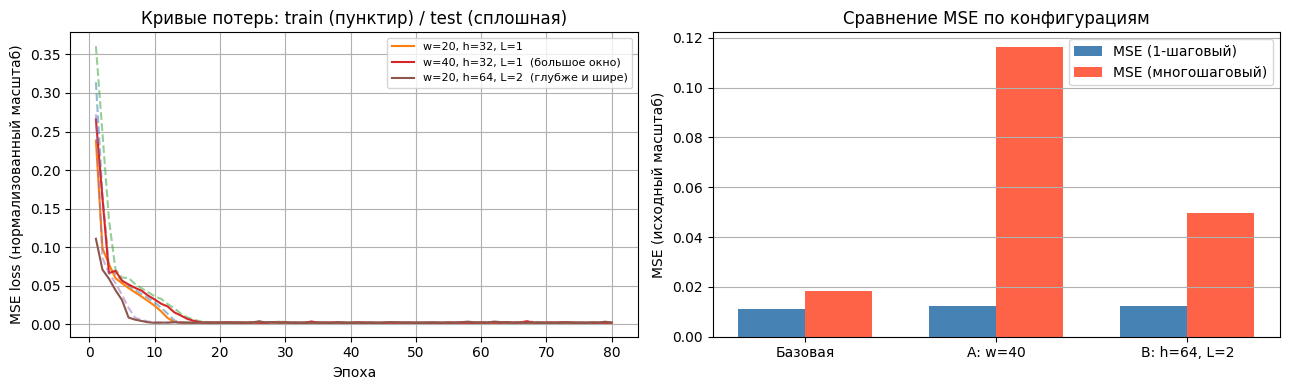

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for res in [res_base, res_A, res_B]:
    ep = np.arange(1, len(res["tr_losses"]) + 1)
    axes[0].plot(ep, res["tr_losses"], linestyle="--", alpha=0.5)
    axes[0].plot(ep, res["te_losses"], label=res["label"])

axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("MSE loss (нормализованный масштаб)")
axes[0].set_title("Кривые потерь: train (пунктир) / test (сплошная)")
axes[0].legend(fontsize=8); axes[0].grid(True)

configs   = ["Базовая", "A: w=40", "B: h=64, L=2"]
mse_one   = [res_base["mse_one"],  res_A["mse_one"],  res_B["mse_one"]]
mse_multi = [res_base["mse_multi"],res_A["mse_multi"],res_B["mse_multi"]]

x = np.arange(len(configs)); w = 0.35
axes[1].bar(x - w/2, mse_one,   w, label="MSE (1-шаговый)",    color="steelblue")
axes[1].bar(x + w/2, mse_multi, w, label="MSE (многошаговый)", color="tomato")
axes[1].set_xticks(x); axes[1].set_xticklabels(configs)
axes[1].set_ylabel("MSE (исходный масштаб)")
axes[1].set_title("Сравнение MSE по конфигурациям")
axes[1].legend(); axes[1].grid(True, axis="y")

plt.tight_layout(); plt.show()

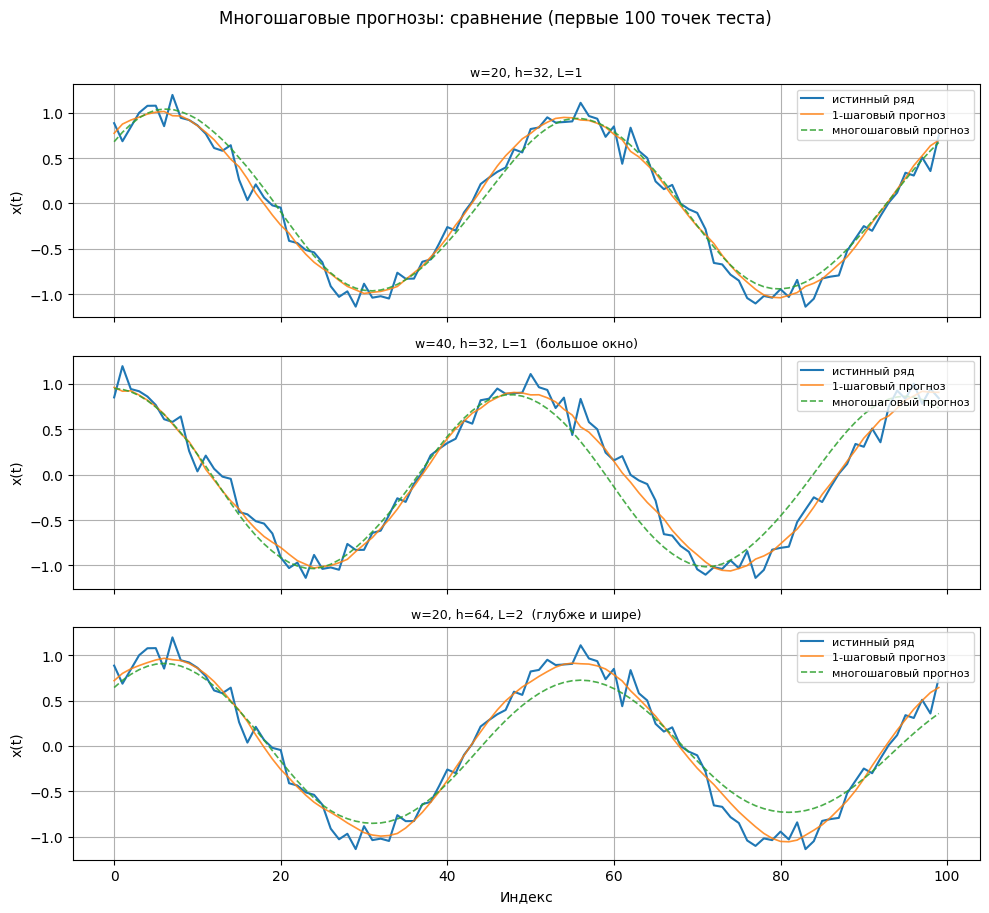

In [15]:
N = 100
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, res in zip(axes, [res_base, res_A, res_B]):
    n = min(N, len(res["yte_orig"]))
    ax.plot(res["yte_orig"][:n],   label="истинный ряд",         linewidth=1.5)
    ax.plot(res["pred_orig"][:n],  label="1-шаговый прогноз",    linewidth=1.2, alpha=0.85)
    ax.plot(res["multi_orig"][:n], label="многошаговый прогноз", linewidth=1.2,
            linestyle="--", alpha=0.85)
    ax.set_title(res["label"], fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True); ax.set_ylabel("x(t)")

axes[-1].set_xlabel("Индекс")
plt.suptitle("Многошаговые прогнозы: сравнение (первые 100 точек теста)", y=1.01)
plt.tight_layout(); plt.show()

In [16]:
final_summary = """
Лучше всего справилась простая модель (окно=20, скрытые=32, слой=1). 
Она быстро обучилась и давала точный прогноз на несколько шагов вперед.
Увеличение окна до 40 ухудшило прогноз на несколько шагов, 
а более сложная модель (64 скрытых, 2 слоя) не дала заметного улучшения, хотя стала намного тяжелее.

Для себя я сделала вывод, что более сложная модель не всегда работает лучше.
Для подобных временных рядов разумно начинать с небольшого окна и простой модели,
а затем постепенно увеличивать размер модели только при необходимости.
"""
print(final_summary)


Лучше всего справилась простая модель (окно=20, скрытые=32, слой=1). 
Она быстро обучилась и давала точный прогноз на несколько шагов вперед.
Увеличение окна до 40 ухудшило прогноз на несколько шагов, 
а более сложная модель (64 скрытых, 2 слоя) не дала заметного улучшения, хотя стала намного тяжелее.

Для себя я сделала вывод, что более сложная модель не всегда работает лучше.
Для подобных временных рядов разумно начинать с небольшого окна и простой модели,
а затем постепенно увеличивать размер модели только при необходимости.

